<a href="https://colab.research.google.com/github/NaziaAfreen015/CSC791-DLBA/blob/main/CSC791_DLBA_ResNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import torchvision.models as models
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
import requests
from io import BytesIO
import torch
import torch.optim as optim
import torch.nn.utils.prune as prune
from torch.utils.data import DataLoader
from torchvision import datasets

import copy
import math
from typing import List, Tuple
import time


import cv2
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


## Preprocess Train

In [ ]:
def preprocess_image(img_path):
  # Define the required transformations
  preprocess = transforms.Compose([
      transforms.Resize(256),
      transforms.RandomHorizontalFlip(),
      transforms.CenterCrop(224),
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
  ])

  # Example of loading an image (replace with your own image path/loading method)
  # For demonstration, we use a sample image URL
  try:
      img = Image.open(img_path)
  except:
      print("Could not load image from URL, using a placeholder.")
      img = Image.new('RGB', (224, 224), color = 'red') # Placeholder if image fails to load

  # Apply transformations and prepare for model input
  img_t = preprocess(img)
  # Add batch dimension: PyTorch expects input as [batch_size, channels, height, width]
  input_tensor = img_t.unsqueeze(0)
  return input_tensor


## Load the CIFAR-10 DATASET

#### Using Keras

In [ ]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# Optional: Normalize pixel values to be between 0 and 1
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

# Print the shape of the data to verify
print(f"Train images shape: {train_images.shape}")
print(f"Test images shape: {test_images.shape}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Train images shape: (50000, 32, 32, 3)
Test images shape: (10000, 32, 32, 3)


#### Using torchvision

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

# Define transformation
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# Download and load training dataset
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4, shuffle=True, num_workers=2)

# Download and load test dataset
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print('CIFAR-10 dataset downloaded and loaded successfully.')

## Get the VGG-16 Model

### Load VGG-16 with Pre-trained Weights on the ImageNet 1K dataset

In [ ]:
# Load the VGG-16 model with default ImageNet weights
vgg16_model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

# You can also use the string alias 'DEFAULT'
# vgg16_model = models.vgg16(weights='DEFAULT')


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 92.1MB/s]


#### Test Pretrained VGG-16

In [ ]:
vgg16_model.eval() # deactivates layers like dropout or batch normalization that behave differently during training and inference.

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

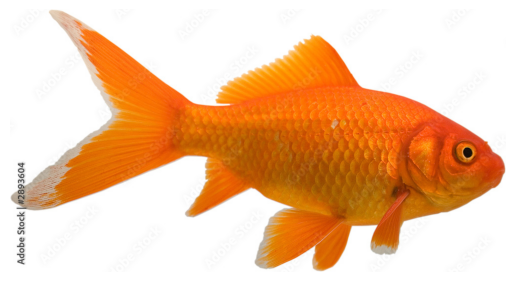

In [ ]:
path = "/content/goldfish.jpg"
img = Image.open(path)

plt.imshow(img)
plt.axis('off') # Hide axes
plt.show()

In [ ]:
path = "/content/goldfish.jpg"
input_tensor = preprocess_image(path)


In [ ]:
with torch.no_grad(): # Disable gradient calculation for inference
    output = vgg16_model(input_tensor)


In [ ]:
# Get the predicted class index
_, predicted_idx = torch.max(output, 1)
print(f"Predicted class index: {predicted_idx.item()}")

# (Optional) Map the index to a human-readable class name if you have a class mapping file (e.g., from ImageNet dataset)
# Example: class_names = [...]
# print(f"Predicted class name: {class_names[predicted_idx.item()]}")


Predicted class index: 1


### Load VGG-16 without Pre-trained Weights

In [ ]:
# Load the VGG-16 model architecture without pre-trained weights
vgg16_scratch = models.vgg16(weights=None)

### Customize the Model for different number of output classes than the original 1000 ImageNet classes

In [ ]:

vgg16_model_customize = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

# Example: Modify the classifier for a 10-class classification problem (like CIFAR-10)
num_classes = 10
vgg16_model.classifier[6] = nn.Linear(4096, num_classes)


## Get the RESNET18 Model

### Load Resnet18 with Pre-trained Weights on the ImageNet 1K dataset

In [ ]:
# Load the ResNet-18 model with default ImageNet1K V1 weights
resnet18_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

#### Test Pretrained Resnet18

In [ ]:
# Set the model to evaluation mode (optional, good practice for inference)
resnet18_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
path = "/content/goldfish.jpg"
input_tensor = preprocess_image(path)

In [ ]:
with torch.no_grad():
    output = resnet18_model(input_tensor)


In [ ]:
_, index = torch.max(output, 1)
# You would typically load the ImageNet class labels (e.g., from a text file)
# to get the human-readable name of the class
print(f"Predicted class index: {index.item()}")


Predicted class index: 1


### Load Resnet18 without Pre-trained Weights

In [ ]:
# Load the ResNet-18 model with random initialization
resnet18_scratch = models.resnet18(weights=None)


## IMP on VGG-16

In [ ]:
# ----------------------------
# 2. Data
# Replace this with your own dataset if needed
# Example here uses CIFAR-10 resized to 224x224 for VGG-16
# ----------------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)


100%|██████████| 170M/170M [00:13<00:00, 12.4MB/s]


In [ ]:
# ----------------------------
# 3. Build VGG-16
# If using pretrained ImageNet weights:
#   models.vgg16(weights="DEFAULT")
# For CIFAR-10 we replace the last classifier layer
# ----------------------------
model = models.vgg16(weights="DEFAULT")
model.classifier[6] = nn.Linear(4096, 10)
model = model.to(device)


In [ ]:
# ----------------------------
# 4. Loss / optimizer
# ----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)

In [ ]:
# ----------------------------
# 5. train the model for one epoch
# ----------------------------
def train_one_epoch(model: nn.Module, loader: DataLoader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

In [ ]:
# ----------------------------
# 5. evaluate the model after train
# ----------------------------
@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

In [ ]:
# ----------------------------
# 6. Collect parameters to prune
# Global unstructured pruning across all Conv2d and Linear weights
# ----------------------------
def get_prunable_parameters(model: nn.Module) -> List[Tuple[nn.Module, str]]:
    parameters_to_prune = []
    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            parameters_to_prune.append((module, "weight"))
    return parameters_to_prune

In [ ]:
# ----------------------------
# 7. Sparsity reporting
# ----------------------------
def get_global_sparsity(model: nn.Module) -> float:
    zero_params = 0
    total_params = 0

    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            weight = module.weight.detach()
            zero_params += torch.sum(weight == 0).item()
            total_params += weight.numel()

    return zero_params / total_params


def print_layerwise_sparsity(model: nn.Module):
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            weight = module.weight.detach()
            zeros = torch.sum(weight == 0).item()
            total = weight.numel()
            print(f"{name:30s} sparsity = {zeros / total:.4f}")


In [ ]:
# ----------------------------
# 8. One iterative pruning step
# amount = fraction of CURRENTLY UNPRUNED weights to prune this round
# ----------------------------
def iterative_prune_step(model: nn.Module, amount: float):
    parameters_to_prune = get_prunable_parameters(model)

    prune.global_unstructured(
        parameters_to_prune,
        pruning_method=prune.L1Unstructured,
        amount=amount,
    )


In [ ]:
# ----------------------------
# 9. Make pruning permanent
# ----------------------------
def remove_pruning_reparam(model: nn.Module):
    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            try:
                prune.remove(module, "weight")
            except ValueError:
                # module was not pruned
                pass


In [ ]:
############ NO NEED FOR PRETRAINED VGG16 ################
# ----------------------------
# 10. Dense pretraining
# If you already have a trained checkpoint, load it here instead
# ----------------------------
dense_pretrain_epochs = 10

print("==> Training dense model")
for epoch in range(dense_pretrain_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, test_loader, criterion, device)
    scheduler.step()

    print(f"[Dense][Epoch {epoch+1}/{dense_pretrain_epochs}] "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.2f}% "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.2f}%")

torch.save(model.state_dict(), "vgg16_dense.pth")

In [ ]:
# ----------------------------
# 11. Fine tune the model
# ----------------------------
def finetune(epoch_count, model, optimizer):
  for epoch in range(epoch_count):
      time_start = time.time()
      train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
      val_loss, val_acc = evaluate(model, test_loader, criterion, device)
      time_end = time.time()
      print(f"[FT Epoch {epoch+1}/{epoch_count}] "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.2f}% "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.2f}%")
      print(f"Time taken: {time_end - time_start:.2f} seconds")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
# ----------------------------
# 12. Iterative magnitude pruning settings
# Example: target 80% sparsity over 8 rounds
# ----------------------------
target_sparsity = 0.80
num_rounds = 8
finetune_epochs_per_round = 3

# prune fraction of remaining weights each round
prune_amount_per_round = 1.0 - (1.0 - target_sparsity) ** (1.0 / num_rounds)

print(f"Per-round prune fraction: {prune_amount_per_round:.4f}")


In [ ]:
# ----------------------------
# 13. IMP loop
# ----------------------------
for round_idx in range(num_rounds):
    print(f"\n==> Pruning round {round_idx + 1}/{num_rounds}")

    # prune additional weights
    iterative_prune_step(model, amount=prune_amount_per_round)

    current_sparsity = get_global_sparsity(model)
    print(f"Global sparsity after pruning: {current_sparsity:.4f}")
    print_layerwise_sparsity(model)

    # IMPORTANT:
    # re-create optimizer after pruning is a common practical choice
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)

    # fine-tune
    finetune(finetune_epochs_per_round, model, optimizer)
    for epoch in range(finetune_epochs_per_round):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, test_loader, criterion, device)

        print(f"[Round {round_idx+1}][FT Epoch {epoch+1}/{finetune_epochs_per_round}] "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.2f}% "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.2f}%")

    torch.save(model.state_dict(), f"vgg16_imp_round_{round_idx+1}.pth")


In [ ]:
# ----------------------------
# 14. Finalize pruning masks
# This removes reparameterization and leaves zeroed weights as real weights
# ----------------------------
remove_pruning_reparam(model)

final_sparsity = get_global_sparsity(model)
print(f"\nFinal global sparsity after remove(): {final_sparsity:.4f}")

torch.save(model.state_dict(), "vgg16_imp_final.pth")